# ANOTHER WTF
When extracting text in batches (i.e there is padding) the representations change a lot for LLAMA-2-13B. If we do it one by one (no padding?) then it is good. This is not really feasible and does not make sense

In [1]:
import torch
import pandas as pd
import plotly.express as px

import numpy as np
import plotly.io as pio
from IPython.display import display, HTML

import torch.nn.functional as F
from tqdm import tqdm
import matplotlib.pyplot as plt

# good default for classic notebook / many Jupyter setups
pio.renderers.default = "iframe"

import sys      
sys.path.insert(0, "/storage/project/r-aivanova7-0/shared/eyas/geometry_of_truth_replication")
from src.data import load_dataset                            
from src.models import load_model
from src.activations import extract_acts, resid_post_hook    
from nnsight import LanguageModel   

from scripts.original_pca_pipeline import run_pca_original
from src.pca import run_pca

/storage/project/r-aivanova7-0/eayesh3/conda_envs/EM_env/lib/python3.14/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [2]:
MODEL_NAME  = "llama-3.2-1b"          # registry key          
HF_ID       = "meta-llama/Llama-3.2-1B"                    
LAYER       = 8                                             
STATEMENT_IDX = 0                    # which statement to    

In [3]:
statements, labels = load_dataset("cities")                  
stmt = [statements[STATEMENT_IDX]]
print(f"Statement: {stmt[0]} | Label is {labels[0]}")      

Statement: The city of Krasnodar is in Russia. | Label is 1


In [4]:
len(statements)

1496

In [5]:
# ── Our pipeline (TransformerLens)                          
#  ────────────────────────────────────────────                 
tl_model, _ = load_model(MODEL_NAME)

Loading LLaMA-3.2-1B from HuggingFace...
Wrapping with TransformerLens...
Loaded pretrained model meta-llama/Llama-3.2-1B into HookedTransformer


In [6]:
tl_acts = extract_acts(                                      
  model=tl_model,  
  statements=statements,                                         
  layers=[LAYER],
  batch_size=64,           # single statement — no padding
  padding_side="left",                                     
)
tl_act = tl_acts[LAYER]    # [1, hidden_size]                
print(f"TL activation shape:  {tl_act.shape}")               
print(f"TL norm:              {tl_act.norm():.4f}")          
print(f"TL mean:              {tl_act.mean():.4f}")          

Extracting activations: 100%|██████████| 24/24 [00:07<00:00,  3.21it/s]

TL activation shape:  torch.Size([1496, 2048])
TL norm:              217.0000
TL mean:              -0.0017


In [7]:
del tl_model                                                 
torch.cuda.empty_cache()

In [8]:
# ── Original pipeline (nnsight) 
#  ───────────────────────────────────────────────              
nn_model = LanguageModel(HF_ID, dtype=torch.bfloat16, device_map="auto")                                           
   


In [9]:
BATCH_SIZE = 32
nn_saved = []
for idx in tqdm(range(0, len(statements), BATCH_SIZE), desc=f"nn-sight batch"):
    batch = list(statements[idx : idx + BATCH_SIZE])
    with nn_model.trace(batch):
        nn_saved.append(nn_model.model.layers[LAYER].output[:, -1,:].save())                                                 

nn_act = torch.cat(nn_saved, dim=0).detach().float().cpu()
print(f"NN activation shape:  {nn_act.shape}")
print(f"NN norm:              {nn_act.norm():.4f}")          
print(f"NN mean:              {nn_act.mean():.4f}")          

nn-sight batch: 100%|██████████| 47/47 [00:08<00:00,  5.32it/s]


NN activation shape:  torch.Size([1496, 2048])
NN norm:              217.4820
NN mean:              -0.0017


In [10]:
del nn_model                                                 
torch.cuda.empty_cache()

torch.Size([1496])
tensor(0.9998)


(array([ 67., 174., 170., 181., 178., 176., 186., 146., 150.,  68.]),
 array([0.99663597, 0.99728155, 0.99792719, 0.99857277, 0.99921834,
        0.99986398, 1.0005095 , 1.00115514, 1.00180078, 1.00244629,
        1.00309193]),
 <BarContainer object of 10 artists>)

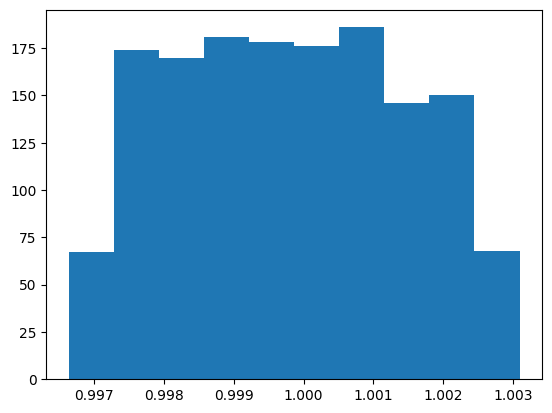

In [11]:
# cosine similarity for each example
cos_sim = F.cosine_similarity(nn_act, tl_act, dim=1)

print(cos_sim.shape)   # (N,)
print(cos_sim.mean())  # average similarity
plt.figure()
plt.hist(cos_sim)

In [12]:
nn_PCA_res = run_pca_original(nn_act, k = 20)

nn_proj = nn_PCA_res.projections.numpy()   # [n_statements, n_pcs]
nn_ev   = nn_PCA_res.explained_var_ratio

print(f"Projections shape: {nn_proj.shape}")
print(f"PC1: {nn_ev[0]:.2%}  PC2: {nn_ev[1]:.2%}  PC3: {nn_ev[2]:.2%}")

Projections shape: (1496, 20)
PC1: 33.22%  PC2: 17.47%  PC3: 8.52%


In [13]:
# ── Load dataset ──────────────────────────────────────────────────────────────
df = pd.read_csv("../datasets/cities.csv")
proj = nn_proj
ev = nn_ev
assert len(df) == proj.shape[0], f"Row count mismatch: {len(df)} vs {proj.shape[0]}"

df["PC1"]   = proj[:, 0]
df["PC2"]   = proj[:, 1]
df["PC3"]   = proj[:, 2]
df["PC4"]   = proj[:, 3]
df["PC5"]   = proj[:, 4]
df["PC6"]   = proj[:, 5]
df["PC7"]   = proj[:, 6]
df["PC8"]   = proj[:, 7]
df["PC9"]   = proj[:, 8]
df["PC10"]   = proj[:, 9]
df["truth"] = df["label"].map({1: "True", 0: "False"})

# ── 2D scatter ────────────────────────────────────────────────────────────────
fig = px.scatter(
    df,
    x="PC1", y="PC2",
    color="truth",
    color_discrete_map={"True": "#d62728", "False": "#1f77b4"},
    hover_data={"statement": True, "city": True, "country": True,
                "correct_country": True, "PC1": False, "PC2": False},
    title=f"{MODEL_NAME} — cities — layer {LAYER}  |  PC1: {ev[0]:.1%}, PC2: {ev[1]:.1%}",
    template="plotly_white",
    opacity=0.7,
)
fig.update_yaxes(scaleanchor="x", scaleratio=1)
fig.update_traces(marker_size=5)
fig.show()

In [14]:
tl_PCA_res = run_pca_original(tl_act.float(), k = 20)

tl_proj = tl_PCA_res.projections.numpy()   # [n_statements, n_pcs]
tl_ev   = tl_PCA_res.explained_var_ratio

print(f"Projections shape: {tl_proj.shape}")
print(f"PC1: {tl_ev[0]:.2%}  PC2: {tl_ev[1]:.2%}  PC3: {tl_ev[2]:.2%}")

Projections shape: (1496, 20)
PC1: 33.18%  PC2: 17.43%  PC3: 8.59%


In [15]:
# ── Load dataset ──────────────────────────────────────────────────────────────
df = pd.read_csv("../datasets/cities.csv")
proj = tl_proj
ev = tl_ev
assert len(df) == proj.shape[0], f"Row count mismatch: {len(df)} vs {proj.shape[0]}"

df["PC1"]   = proj[:, 0]
df["PC2"]   = proj[:, 1]
df["PC3"]   = proj[:, 2]
df["PC4"]   = proj[:, 3]
df["PC5"]   = proj[:, 4]
df["PC6"]   = proj[:, 5]
df["PC7"]   = proj[:, 6]
df["PC8"]   = proj[:, 7]
df["PC9"]   = proj[:, 8]
df["PC10"]   = proj[:, 9]
df["truth"] = df["label"].map({1: "True", 0: "False"})

# ── 2D scatter ────────────────────────────────────────────────────────────────
fig = px.scatter(
    df,
    x="PC1", y="PC2",
    color="truth",
    color_discrete_map={"True": "#d62728", "False": "#1f77b4"},
    hover_data={"statement": True, "city": True, "country": True,
                "correct_country": True, "PC1": False, "PC2": False},
    title=f"{MODEL_NAME} — cities — layer {LAYER}  |  PC1: {ev[0]:.1%}, PC2: {ev[1]:.1%}",
    template="plotly_white",
    opacity=0.7,
)
fig.update_yaxes(scaleanchor="x", scaleratio=1)
fig.update_traces(marker_size=5)
fig.show()

In [16]:
nn_PCA_res = run_pca(nn_act, k = 20, scale = 0)

nn_proj = nn_PCA_res.projections.numpy()   # [n_statements, n_pcs]
nn_ev   = nn_PCA_res.explained_var_ratio

print(f"Projections shape: {nn_proj.shape}")
print(f"PC1: {nn_ev[0]:.2%}  PC2: {nn_ev[1]:.2%}  PC3: {nn_ev[2]:.2%}")

Projections shape: (1496, 20)
PC1: 33.22%  PC2: 17.47%  PC3: 8.52%


In [17]:
# ── Load dataset ──────────────────────────────────────────────────────────────
df = pd.read_csv("../datasets/cities.csv")
proj = nn_proj
ev = nn_ev
assert len(df) == proj.shape[0], f"Row count mismatch: {len(df)} vs {proj.shape[0]}"

df["PC1"]   = proj[:, 0]
df["PC2"]   = proj[:, 1]
df["PC3"]   = proj[:, 2]
df["PC4"]   = proj[:, 3]
df["PC5"]   = proj[:, 4]
df["PC6"]   = proj[:, 5]
df["PC7"]   = proj[:, 6]
df["PC8"]   = proj[:, 7]
df["PC9"]   = proj[:, 8]
df["PC10"]   = proj[:, 9]
df["truth"] = df["label"].map({1: "True", 0: "False"})

# ── 2D scatter ────────────────────────────────────────────────────────────────
fig = px.scatter(
    df,
    x="PC1", y="PC2",
    color="truth",
    color_discrete_map={"True": "#d62728", "False": "#1f77b4"},
    hover_data={"statement": True, "city": True, "country": True,
                "correct_country": True, "PC1": False, "PC2": False},
    title=f"{MODEL_NAME} — cities — layer {LAYER}  |  PC1: {ev[0]:.1%}, PC2: {ev[1]:.1%}",
    template="plotly_white",
    opacity=0.7,
)
fig.update_yaxes(scaleanchor="x", scaleratio=1)
fig.update_traces(marker_size=5)
fig.show()

In [18]:
tl_PCA_res = run_pca(tl_act.float(), k = 20)

tl_proj = tl_PCA_res.projections.numpy()   # [n_statements, n_pcs]
tl_ev   = tl_PCA_res.explained_var_ratio

print(f"Projections shape: {tl_proj.shape}")
print(f"PC1: {tl_ev[0]:.2%}  PC2: {tl_ev[1]:.2%}  PC3: {tl_ev[2]:.2%}")

Projections shape: (1496, 20)
PC1: 33.18%  PC2: 17.43%  PC3: 8.59%


In [19]:
# ── Load dataset ──────────────────────────────────────────────────────────────
df = pd.read_csv("../datasets/cities.csv")
proj = nn_proj
ev = nn_ev
assert len(df) == proj.shape[0], f"Row count mismatch: {len(df)} vs {proj.shape[0]}"

df["PC1"]   = proj[:, 0]
df["PC2"]   = proj[:, 1]
df["PC3"]   = proj[:, 2]
df["PC4"]   = proj[:, 3]
df["PC5"]   = proj[:, 4]
df["PC6"]   = proj[:, 5]
df["PC7"]   = proj[:, 6]
df["PC8"]   = proj[:, 7]
df["PC9"]   = proj[:, 8]
df["PC10"]   = proj[:, 9]
df["truth"] = df["label"].map({1: "True", 0: "False"})

# ── 2D scatter ────────────────────────────────────────────────────────────────
fig = px.scatter(
    df,
    x="PC1", y="PC2",
    color="truth",
    color_discrete_map={"True": "#d62728", "False": "#1f77b4"},
    hover_data={"statement": True, "city": True, "country": True,
                "correct_country": True, "PC1": False, "PC2": False},
    title=f"{MODEL_NAME} — cities — layer {LAYER}  |  PC1: {ev[0]:.1%}, PC2: {ev[1]:.1%}",
    template="plotly_white",
    opacity=0.7,
)
fig.update_yaxes(scaleanchor="x", scaleratio=1)
fig.update_traces(marker_size=5)
fig.show()

# Things look good so far, let's try the pipeline

In [20]:
from scripts.pca_pipeline import extract_for_model, sample_dataset
from src.activations import save_acts, load_acts

In [28]:
extract_for_model(MODEL_NAME, ["cities"],[8],"test5", batch_size=64, max_rows=2048, seed=42, padding_side="right",shuffle=False)


  Loading model to extract 1 missing (dataset, layer) pairs...
Loading LLaMA-3.2-1B from HuggingFace...
Wrapping with TransformerLens...
Loaded pretrained model meta-llama/Llama-3.2-1B into HookedTransformer
  Dataset: cities (1496 rows) — extracting layers [8]


Extracting activations: 100%|██████████| 24/24 [00:07<00:00,  3.27it/s]


    Saved to test5/llama-3.2-1b/cities/
  GPU memory released.


In [34]:
acts = load_acts(MODEL_NAME,"cities",8,"test4", center=False)

torch.Size([1496])
tensor(0.9999)


(array([ 58., 174., 173., 188., 167., 185., 187., 148., 149.,  67.]),
 array([0.99672312, 0.99737424, 0.99802536, 0.99867648, 0.9993276 ,
        0.99997866, 1.00062978, 1.0012809 , 1.00193202, 1.00258315,
        1.00323427]),
 <BarContainer object of 10 artists>)

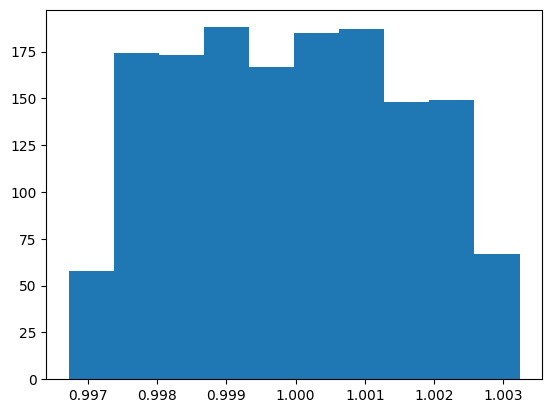

In [35]:
# cosine similarity for each example
cos_sim = F.cosine_similarity(acts, tl_act, dim=1)

print(cos_sim.shape)   # (N,)
print(cos_sim.mean())  # average similarity
plt.figure()
plt.hist(cos_sim)

In [24]:
statements_2, labels_2 = sample_dataset(statements, labels, 2048, 42, True)

In [25]:
save_acts(tl_acts, MODEL_NAME, "cities", "test2", batch_size=64)

In [26]:
tl_acts_2 = load_acts(MODEL_NAME,"cities",8,"test2", center=False)

In [36]:
result = run_pca(acts, k=10, center=True, scale=True)

In [37]:
nn_proj = result.projections.numpy()   # [n_statements, n_pcs]
nn_ev   = result.explained_var_ratio

print(f"Projections shape: {nn_proj.shape}")
print(f"PC1: {nn_ev[0]:.2%}  PC2: {nn_ev[1]:.2%}  PC3: {nn_ev[2]:.2%}")

Projections shape: (1496, 10)
PC1: 23.81%  PC2: 15.93%  PC3: 9.06%


In [38]:
# ── Load dataset ──────────────────────────────────────────────────────────────
df = pd.read_csv("../datasets/cities.csv")
proj = nn_proj
ev = nn_ev
assert len(df) == proj.shape[0], f"Row count mismatch: {len(df)} vs {proj.shape[0]}"

df["PC1"]   = proj[:, 0]
df["PC2"]   = proj[:, 1]
df["PC3"]   = proj[:, 2]
df["PC4"]   = proj[:, 3]
df["PC5"]   = proj[:, 4]
df["PC6"]   = proj[:, 5]
df["PC7"]   = proj[:, 6]
df["PC8"]   = proj[:, 7]
df["PC9"]   = proj[:, 8]
df["PC10"]   = proj[:, 9]
df["truth"] = df["label"].map({1: "True", 0: "False"})

# ── 2D scatter ────────────────────────────────────────────────────────────────
fig = px.scatter(
    df,
    x="PC1", y="PC2",
    color="truth",
    color_discrete_map={"True": "#d62728", "False": "#1f77b4"},
    hover_data={"statement": True, "city": True, "country": True,
                "correct_country": True, "PC1": False, "PC2": False},
    title=f"{MODEL_NAME} — cities — layer {LAYER}  |  PC1: {ev[0]:.1%}, PC2: {ev[1]:.1%}",
    template="plotly_white",
    opacity=0.7,
)
fig.update_yaxes(scaleanchor="x", scaleratio=1)
fig.update_traces(marker_size=5)
fig.show()